# Step 2: Multi-source Dijkstra — Voronoi Visualization

Build a cost map from the background-corrected image, then run multi-source Dijkstra
with all annotation component pixels as simultaneous sources (cost = 0).

Each pixel records:
- **component_id**: which annotation component "owns" it
- **cost**: accumulated traversal cost to reach it

**Goal**: Visualize the Voronoi partition and verify that region boundaries
naturally fall in dark areas between fibers.

In [1]:
import numpy as np
import cv2
import skimage as ski
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
from skimage.measure import label, regionprops
from scipy import ndimage
import heapq

from neural_reconstruction.core.preprocessing import dilate_epidermis_vertically
from neural_reconstruction.dataset import DatasetLoader

BASE_PATH = Path('/home/pony/projects/ienf_q/data_0331')
IMAGE_ID  = 'S1585-2_b'

## 1. Preprocessing (following preprocess.ipynb)

In [2]:
image      = cv2.imread(str(BASE_PATH / IMAGE_ID / 'image.png'),      cv2.IMREAD_COLOR_RGB)[:, :, 1]
mask       = cv2.imread(str(BASE_PATH / IMAGE_ID / 'mask.png'),       cv2.IMREAD_GRAYSCALE)
annotation = cv2.imread(str(BASE_PATH / IMAGE_ID / 'weka.png'),       cv2.IMREAD_GRAYSCALE)

# ROI mask
roi_mask = dilate_epidermis_vertically(mask, offset_px=50)

# Background removal
kernel     = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (51, 51))
background = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)
image      = cv2.subtract(image, background)

roi_image      = cv2.bitwise_and(image,      image,      mask=roi_mask)
roi_annotation = cv2.bitwise_and(annotation, annotation, mask=roi_mask)

# CLAHE + Sato vesselness
clahe     = cv2.createCLAHE(clipLimit=20.0, tileGridSize=(16, 16))
roi_image = clahe.apply(roi_image)
roi_image = ski.filters.sato(roi_image, sigmas=range(3, 8), black_ridges=False)
roi_image = (roi_image - roi_image.min()) / (roi_image.max() - roi_image.min()) * 255
roi_image = roi_image.astype(np.uint8)

print(f'Image shape: {roi_image.shape}')
print(f'Annotation pixels: {(roi_annotation > 127).sum()}')

Image shape: (1946, 5632)
Annotation pixels: 13950


## 2. Cost Map

Bright pixels (nerve tissue) = low traversal cost.  
Dark pixels (background) = high cost.

`cost = 1 - normalized_intensity`

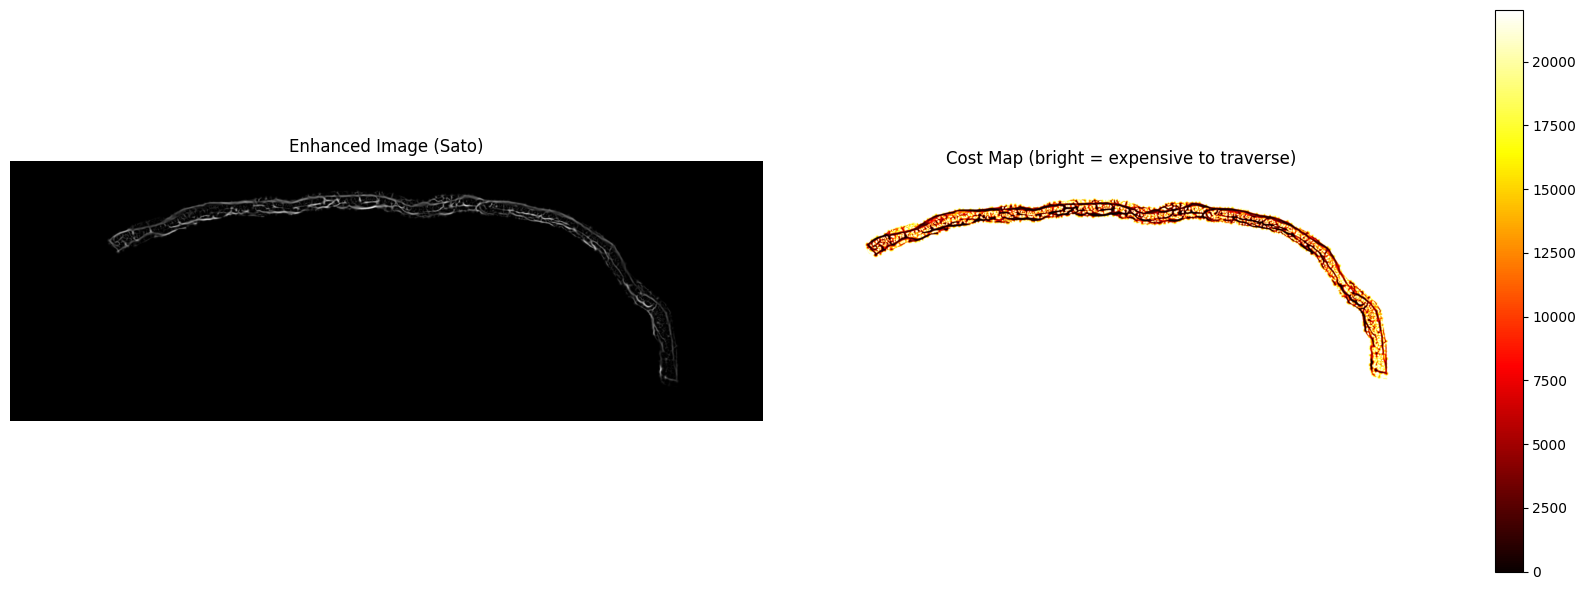

In [3]:
# Normalize to [0, 1] and invert: bright -> low cost
intensity_norm = roi_image.astype(np.float32) / 255.0
cost_map = 1.0 - intensity_norm  # float32, range [0, 1]
cost_map = np.exp(cost_map * 10) - 1.0  # Exponential to amplify differences

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(roi_image, cmap='gray')
axes[0].set_title('Enhanced Image (Sato)')
axes[0].axis('off')
im = axes[1].imshow(cost_map, cmap='hot')
axes[1].set_title('Cost Map (bright = expensive to traverse)')
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 3. Multi-source Dijkstra

All annotation component pixels start at cost 0.  
Each pixel tracks `(component_id, accumulated_cost)`.

In [4]:
def get_components(binary_img, min_area=0):
    labeled = label(binary_img, connectivity=1)
    for p in regionprops(labeled):
        if p.area < min_area:
            labeled[labeled == p.label] = 0
    labeled, _ = ndimage.label(labeled > 0)
    return labeled


def multi_source_dijkstra(cost_map, annot_labeled, connectivity=8):
    """
    Multi-source Dijkstra on a 2D cost map.

    Args:
        cost_map:      float32 array (H, W), per-pixel traversal cost
        annot_labeled: int array (H, W), 0=background, >0=component ID
        connectivity:  4 or 8

    Returns:
        owner_map: int32 array (H, W) — which component owns each pixel (0=unvisited)
        dist_map:  float32 array (H, W) — accumulated cost to reach each pixel
    """
    H, W = cost_map.shape
    INF = np.inf

    if connectivity == 4:
        neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    else:  # 8
        neighbors = [(-1, -1), (-1, 0), (-1, 1),
                     ( 0, -1),           ( 0, 1),
                     ( 1, -1), ( 1, 0),  ( 1, 1)]

    dist_map  = np.full((H, W), INF, dtype=np.float32)
    owner_map = np.zeros((H, W), dtype=np.int32)

    # Initialize: all annotation pixels at cost 0
    heap = []  # (cost, y, x, component_id)
    ys, xs = np.where(annot_labeled > 0)
    for y, x in zip(ys, xs):
        cid = int(annot_labeled[y, x])
        dist_map[y, x]  = 0.0
        owner_map[y, x] = cid
        heapq.heappush(heap, (0.0, y, x, cid))

    while heap:
        d, y, x, cid = heapq.heappop(heap)

        # Skip if we already found a better path
        if d > dist_map[y, x]:
            continue

        for dy, dx in neighbors:
            ny, nx = y + dy, x + dx
            if not (0 <= ny < H and 0 <= nx < W):
                continue

            # Edge cost: cost of entering the neighbor pixel
            new_dist = d + float(cost_map[ny, nx])

            if new_dist < dist_map[ny, nx]:
                dist_map[ny, nx]  = new_dist
                owner_map[ny, nx] = cid
                heapq.heappush(heap, (new_dist, ny, nx, cid))

    return owner_map, dist_map

In [5]:
annotation_bin = (roi_annotation > 127).astype(np.uint8)
annot_labeled  = get_components(annotation_bin)
n_components   = annot_labeled.max()
print(f'Annotation components: {n_components}')

print('Running multi-source Dijkstra...')
owner_map, dist_map = multi_source_dijkstra(cost_map, annot_labeled, connectivity=8)
print('Done.')
print(f'  Pixels reached: {(owner_map > 0).sum()}')
print(f'  Max cost:       {dist_map[dist_map < np.inf].max():.2f}')

Annotation components: 861
Running multi-source Dijkstra...
Done.
  Pixels reached: 10959872
  Max cost:       31613990.00


## 4. Voronoi Visualization

Color each pixel by which annotation component owns it.  
Check: do the region boundaries fall in dark areas (background) between fibers?

In [6]:
def make_voronoi_rgb(owner_map, roi_mask=None):
    """Color each owned pixel by a random color per component."""
    n = owner_map.max()
    rng = np.random.default_rng(42)
    colors = rng.integers(60, 255, size=(n + 1, 3), dtype=np.uint8)
    colors[0] = 0  # background = black

    rgb = colors[owner_map]  # (H, W, 3)

    if roi_mask is not None:
        rgb[roi_mask == 0] = 0

    return rgb


def boundary_overlay(owner_map, image_gray, roi_mask=None, alpha=0.5):
    """Overlay Voronoi boundaries on the image."""
    # Detect boundaries: pixel differs from any neighbor
    from scipy.ndimage import generic_filter

    def is_boundary(patch):
        center = patch[4]  # 3x3 patch, center = index 4
        return 1.0 if center > 0 and np.any(patch != center) else 0.0

    boundary = generic_filter(owner_map.astype(float), is_boundary, size=3)
    boundary = boundary > 0

    img_rgb = np.stack([image_gray] * 3, axis=-1).astype(np.uint8)
    img_rgb[boundary] = [255, 0, 0]  # red boundaries

    if roi_mask is not None:
        img_rgb[roi_mask == 0] = 0

    return img_rgb, boundary


voronoi_rgb = make_voronoi_rgb(owner_map, roi_mask)
boundary_rgb, boundary_mask = boundary_overlay(owner_map, roi_image, roi_mask)


fig_size_x = 128
fig_size_y = int(roi_image.shape[0] / roi_image.shape[1] * fig_size_x)

fig, axes = plt.subplots(1, 1, figsize=(fig_size_x, fig_size_y))

# axes[0].imshow(roi_image, cmap='gray')
# axes[0].set_title('Enhanced Image')
# axes[0].axis('off')

axes.imshow(voronoi_rgb)
axes.set_title(f'Voronoi Partition ({n_components} components)')
axes.axis('off')

# axes[2].imshow(boundary_rgb)
# axes[2].set_title('Voronoi Boundaries on Image\n(red = partition boundary)')
# axes[2].axis('off')

plt.suptitle(f'Sample: {IMAGE_ID}', fontsize=13)
plt.tight_layout()
plt.savefig(f'{IMAGE_ID}_voronoi.png')
plt.close(fig)

In [7]:
# # Zoomed-in view of a region of interest
# # Adjust the crop window to inspect specific areas
# H, W = roi_image.shape
# cy, cx = H // 2, W // 2  # center of crop (adjust as needed)
# half   = 300

# y0, y1 = max(0, cy - half), min(H, cy + half)
# x0, x1 = max(0, cx - half), min(W, cx + half)

# fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# axes[0].imshow(roi_image[y0:y1, x0:x1], cmap='gray')
# axes[0].set_title('Enhanced Image (zoomed)')
# axes[0].axis('off')

# axes[1].imshow(voronoi_rgb[y0:y1, x0:x1])
# axes[1].set_title('Voronoi Partition (zoomed)')
# axes[1].axis('off')

# axes[2].imshow(boundary_rgb[y0:y1, x0:x1])
# axes[2].set_title('Boundaries on Image (zoomed)')
# axes[2].axis('off')

# plt.tight_layout()
# plt.show()

## 5. Boundary Quality Check

Quantify: what fraction of boundary pixels fall in dark regions (low intensity)?
If boundaries tend to land in dark areas, the cost map is guiding expansion correctly.

Intensity statistics:
  All owned pixels  — mean: 37.2, median: 24.0
  Boundary pixels   — mean: 33.4, median: 16.0

  Fraction of boundary pixels in bottom-30% intensity: 38.2%
  (If >> 30%, boundaries prefer dark areas — cost map is working)


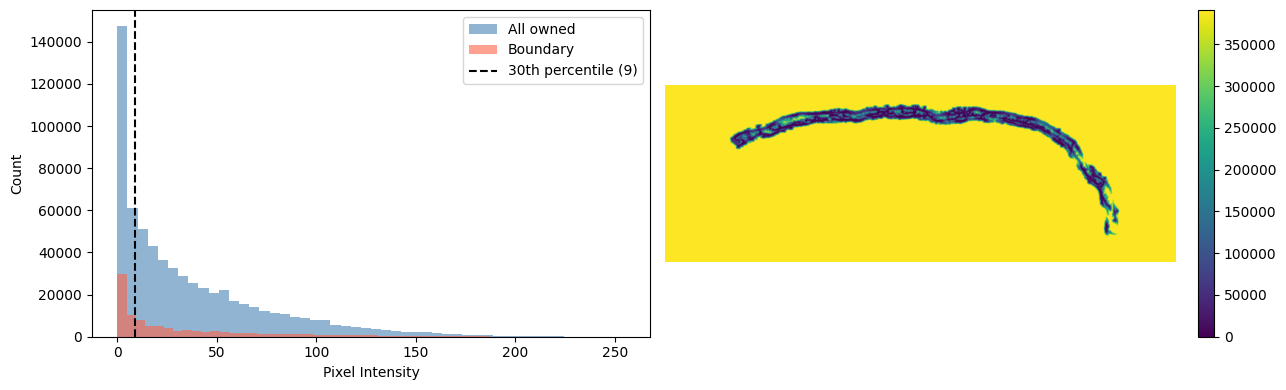

In [8]:
# Sample intensity at boundary pixels vs all owned pixels
all_owned = (owner_map > 0) & (roi_mask > 0)
boundary_in_roi = boundary_mask & (roi_mask > 0)

intensity_owned    = roi_image[all_owned].astype(float)
intensity_boundary = roi_image[boundary_in_roi].astype(float)

print('Intensity statistics:')
print(f'  All owned pixels  — mean: {intensity_owned.mean():.1f}, median: {np.median(intensity_owned):.1f}')
print(f'  Boundary pixels   — mean: {intensity_boundary.mean():.1f}, median: {np.median(intensity_boundary):.1f}')
print()
thresh = np.percentile(intensity_owned, 30)  # bottom 30% = "dark"
pct_dark = (intensity_boundary < thresh).mean() * 100
print(f'  Fraction of boundary pixels in bottom-30% intensity: {pct_dark:.1f}%')
print(f'  (If >> 30%, boundaries prefer dark areas — cost map is working)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(intensity_owned,    bins=50, alpha=0.6, label='All owned', color='steelblue')
axes[0].hist(intensity_boundary, bins=50, alpha=0.6, label='Boundary',  color='tomato')
axes[0].axvline(thresh, color='black', linestyle='--', label=f'30th percentile ({thresh:.0f})')
axes[0].set_xlabel('Pixel Intensity')
axes[0].set_ylabel('Count')
axes[0].legend()

im = axes[1].imshow(dist_map, cmap='viridis',
                    vmax=np.percentile(dist_map[all_owned], 95))
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## 6. Meeting Points Between Components

Scan the `owner_map`: whenever pixel A and neighbor pixel B belong to different components,
that's a **meeting point**. The meeting cost = `dist[A] + dist[B]`.

For each component pair, keep only the **minimum** meeting cost (the cheapest connection).

In [10]:
def find_meeting_points(owner_map, dist_map):
    """
    Find the minimum-cost meeting point for every component pair.

    Uses numpy shifts to avoid Python loops over pixels.

    Returns:
        connections: dict {(A, B): {'cost': float, 'y': int, 'x': int}}
                     where A < B and cost is the minimum meeting cost
    """
    # Check 4 shift directions — each covers its symmetric counterpart
    shifts = [(0, 1), (1, 0), (1, 1), (1, -1)]
    connections = {}

    for dy, dx in shifts:
        # Slice owner_map and dist_map for pixel and its shifted neighbor
        if dy > 0:
            oa = owner_map[:-dy, :]
            ob = owner_map[dy:, :]
            da = dist_map[:-dy, :]
            db = dist_map[dy:, :]
            ys_offset = 0
        else:
            oa = owner_map
            ob = owner_map
            da = dist_map
            db = dist_map
            ys_offset = 0

        if dx > 0:
            oa = oa[:, :-dx];  ob = ob[:, dx:]
            da = da[:, :-dx];  db = db[:, dx:]
            xs_offset = 0
        elif dx < 0:
            oa = oa[:, -dx:];  ob = ob[:, :dx]
            da = da[:, -dx:];  db = db[:, :dx]
            xs_offset = -dx
        else:
            xs_offset = 0

        # Meeting mask: both owned and different components
        meet = (oa > 0) & (ob > 0) & (oa != ob)
        ys_local, xs_local = np.where(meet)
        if len(ys_local) == 0:
            continue

        a_ids = oa[ys_local, xs_local].astype(int)
        b_ids = ob[ys_local, xs_local].astype(int)
        costs = da[ys_local, xs_local] + db[ys_local, xs_local]

        # Global pixel coordinates (use the 'a' pixel as the meeting marker)
        global_y = ys_local + ys_offset
        global_x = xs_local + xs_offset

        for a, b, cost, gy, gx in zip(a_ids, b_ids, costs, global_y, global_x):
            key = (min(a, b), max(a, b))
            if key not in connections or cost < connections[key]['cost']:
                connections[key] = {'cost': float(cost), 'y': int(gy), 'x': int(gx)}

    return connections


connections = find_meeting_points(owner_map, dist_map)
costs_all = np.array([v['cost'] for v in connections.values()])

print(f'Component pairs with a meeting point: {len(connections)}')
print(f'Meeting cost — mean: {costs_all.mean():.2f}, median: {np.median(costs_all):.2f}, '
      f'min: {costs_all.min():.2f}, max: {costs_all.max():.2f}')

Component pairs with a meeting point: 2449
Meeting cost — mean: 743674.87, median: 35556.17, min: 0.00, max: 62506064.00


## 7. GT Validation: Same-fiber vs Cross-fiber Meeting Costs

Map each annotation component to its GT fiber (majority overlap),
then classify every component pair as **same-fiber** or **cross-fiber**.

If the cost map is guiding expansion correctly, same-fiber pairs should have clearly lower meeting costs.

In [11]:
# Load GT label and find fibers
label_img  = cv2.imread(str(BASE_PATH / IMAGE_ID / 'label.png'), cv2.IMREAD_GRAYSCALE)
gt_labeled, n_gt = ndimage.label(label_img > 127)
print(f'GT fibers: {n_gt}')

# Map each annotation component -> dominant GT fiber (majority vote)
annot_to_gt = {}  # annot_id -> gt_id (0 = no GT overlap)

for a_id in range(1, n_components + 1):
    a_mask   = annot_labeled == a_id
    gt_under = gt_labeled[a_mask]
    gt_under = gt_under[gt_under > 0]

    if len(gt_under) == 0:
        annot_to_gt[a_id] = 0
    else:
        unique, counts = np.unique(gt_under, return_counts=True)
        annot_to_gt[a_id] = int(unique[counts.argmax()])

n_with_gt = sum(v > 0 for v in annot_to_gt.values())
print(f'Annotation components with GT mapping: {n_with_gt}/{n_components}')

GT fibers: 99
Annotation components with GT mapping: 856/861


In [12]:
# Classify connections: same-fiber / cross-fiber / unknown
same_fiber_costs  = []
cross_fiber_costs = []
unknown_costs     = []

for (a, b), info in connections.items():
    gt_a = annot_to_gt.get(a, 0)
    gt_b = annot_to_gt.get(b, 0)

    if gt_a == 0 or gt_b == 0:
        unknown_costs.append(info['cost'])
    elif gt_a == gt_b:
        same_fiber_costs.append(info['cost'])
    else:
        cross_fiber_costs.append(info['cost'])

same  = np.array(same_fiber_costs)
cross = np.array(cross_fiber_costs)

print('Meeting cost by connection type:')
print(f'  Same-fiber  (n={len(same):4d}): '
      f'mean={same.mean():.2f},  median={np.median(same):.2f},  p90={np.percentile(same, 90):.2f}')
print(f'  Cross-fiber (n={len(cross):4d}): '
      f'mean={cross.mean():.2f},  median={np.median(cross):.2f},  p10={np.percentile(cross, 10):.2f}')
print(f'  Unknown     (n={len(unknown_costs):4d})')
print()
# Key separability metric: how many same-fiber pairs are cheaper than the cross-fiber median?
cross_median = np.median(cross)
separability = (same < cross_median).mean() * 100
print(f'  Same-fiber costs below cross-fiber median: {separability:.1f}%')
print(f'  (Ideal >> 50%: same-fiber connections are consistently cheaper)')

Meeting cost by connection type:
  Same-fiber  (n=1627): mean=87059.21,  median=4782.26,  p90=265834.82
  Cross-fiber (n= 789): mean=2036625.70,  median=226876.33,  p10=22897.19
  Unknown     (n=  33)

  Same-fiber costs below cross-fiber median: 86.6%
  (Ideal >> 50%: same-fiber connections are consistently cheaper)


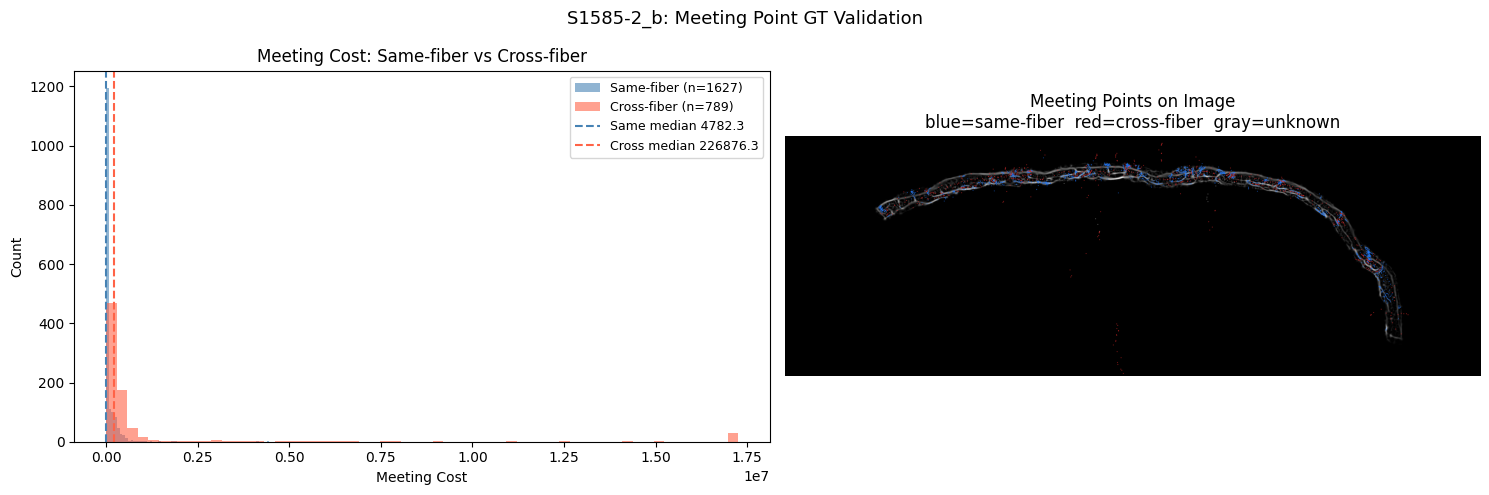

In [13]:
clip_pct = 99
clip_val = np.percentile(np.concatenate([same, cross]), clip_pct)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Cost distribution
axes[0].hist(np.clip(same,  0, clip_val), bins=60, alpha=0.6,
             label=f'Same-fiber (n={len(same)})',  color='steelblue')
axes[0].hist(np.clip(cross, 0, clip_val), bins=60, alpha=0.6,
             label=f'Cross-fiber (n={len(cross)})', color='tomato')
axes[0].axvline(np.median(same),  color='steelblue', linestyle='--', linewidth=1.5,
                label=f'Same median {np.median(same):.1f}')
axes[0].axvline(np.median(cross), color='tomato',    linestyle='--', linewidth=1.5,
                label=f'Cross median {np.median(cross):.1f}')
axes[0].set_xlabel('Meeting Cost')
axes[0].set_ylabel('Count')
axes[0].set_title('Meeting Cost: Same-fiber vs Cross-fiber')
axes[0].legend(fontsize=9)

# Spatial: meeting points colored by type
viz = np.stack([roi_image] * 3, axis=-1).astype(np.uint8)
for (a, b), info in connections.items():
    gt_a = annot_to_gt.get(a, 0)
    gt_b = annot_to_gt.get(b, 0)
    y, x = info['y'], info['x']
    if gt_a > 0 and gt_b > 0 and gt_a == gt_b:
        color = (30, 120, 255)   # blue = same-fiber
    elif gt_a > 0 and gt_b > 0:
        color = (255, 50, 50)    # red = cross-fiber
    else:
        color = (160, 160, 160)  # gray = unknown
    cv2.circle(viz, (x, y), radius=3, color=color, thickness=-1)

axes[1].imshow(viz)
axes[1].set_title('Meeting Points on Image\nblue=same-fiber  red=cross-fiber  gray=unknown')
axes[1].axis('off')

plt.suptitle(f'{IMAGE_ID}: Meeting Point GT Validation', fontsize=13)
plt.tight_layout()
plt.show()

## Conclusion

**Verdict:** Does the cost map quality look sufficient to guide fiber expansion in Step 3?

- Voronoi boundaries fall in dark areas → YES, cost map is working
- Boundaries cut through bright fibers → cost map needs adjustment (try different Sato sigmas, or cost function)